In [48]:
#Step1-Import libraries
import pandas as pd #handale data(add,delete, update,filter)
import numpy as np  #fast mathematical and numerical calculation
import matplotlib.pyplot as plt #create graphs and visualizing data
import seaborn as sns #advanced visualization


In [49]:
#Step2- load data
data=pd.read_excel("C:/Users/vijay/OneDrive/Desktop/project4/Book1.xlsx") #import file

In [50]:
data.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB


In [52]:
data.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [53]:
#data cleaning
#column name correction
data.rename(columns={'Prize':'Price'},inplace=True)

#remove comas from Prize and convert to intager
data["Price"]=data["Price"].astype(str).str.replace(",","").astype(float)

In [54]:
#drop unnamed columns
data=data.drop("Unnamed: 0",axis=1)

In [55]:
data.duplicated().sum()

np.int64(10)

In [56]:
#fill numeric missing values with mean
num_cols=data.select_dtypes(include=['int64','float64']).columns
data[num_cols]=data[num_cols].fillna(data[num_cols].mean())

In [57]:
#fill categorical missing values with mode
cat_cols=data.select_dtypes(include=['object']).columns 
for col in cat_cols:
    data[col].fillna(data[col].mode()[0],inplace=True)

C:\Users\vijay\AppData\Local\Temp\ipykernel_9780\4251580892.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0],inplace=True)


In [58]:
#remove duplicates
data.drop_duplicates(inplace=True)

In [59]:
#columns count
data.columns.value_counts()

Model            1
Colour           1
Memory           1
RAM              1
Battery_         1
Rear Camera      1
Front Camera     1
AI Lens          1
Mobile Height    1
Processor_       1
Price            1
Name: count, dtype: int64

In [60]:
#total row=531 and columns=11
data.shape

(531, 11)

In [61]:
#statistics
data.describe().round()

,Memory,RAM,Battery_,AI Lens,Mobile Height,Price
count,531.0,531.0,531.0,531.0,531.0,531.0
mean,111.0,5.0,4874.0,0.0,16.0,16306.0
std,61.0,2.0,766.0,0.0,2.0,10847.0
min,16.0,2.0,800.0,0.0,4.0,920.0
25%,64.0,4.0,5000.0,0.0,17.0,9368.0
50%,128.0,6.0,5000.0,0.0,17.0,13999.0
75%,128.0,8.0,5000.0,0.0,17.0,19338.0
max,256.0,8.0,7000.0,1.0,42.0,80999.0


In [62]:
#Correlation with Price
correlation = data.corr(numeric_only=True)['Price'].sort_values(ascending=False) 
print("\nCorrelation with Price:") 
print(correlation)


Correlation with Price:
Price            1.000000
Memory           0.563535
RAM              0.529474
Mobile Height    0.168303
Battery_        -0.046250
AI Lens         -0.156336
Name: Price, dtype: float64


In [63]:
#extract brand from model
data["Brand"]=data["Model"].str.split().str[0]
data["Brand"]=data["Brand"].str.upper().str.strip()
brand_counts=data["Brand"].value_counts()
brand_counts
print("\nBrand Counts:\n",data["Brand"].value_counts())
print("Total Entries:",data["Brand"].count())
print("Total_Brands:",data["Brand"].nunique())


Brand Counts:
 Brand
REALME       97
REDMI        74
INFINIX      65
VIVO         60
POCO         58
SAMSUNG      53
MOTOROLA     45
TECNO        16
OPPO         16
MICROMAX     13
GOOGLE        9
ONEPLUS       5
APPLE         5
NOKIA         3
ITEL          3
NOTHING       2
IQOO          2
I             2
LAVA          2
MICROMAX1     1
Name: count, dtype: int64
Total Entries: 531
Total_Brands: 20


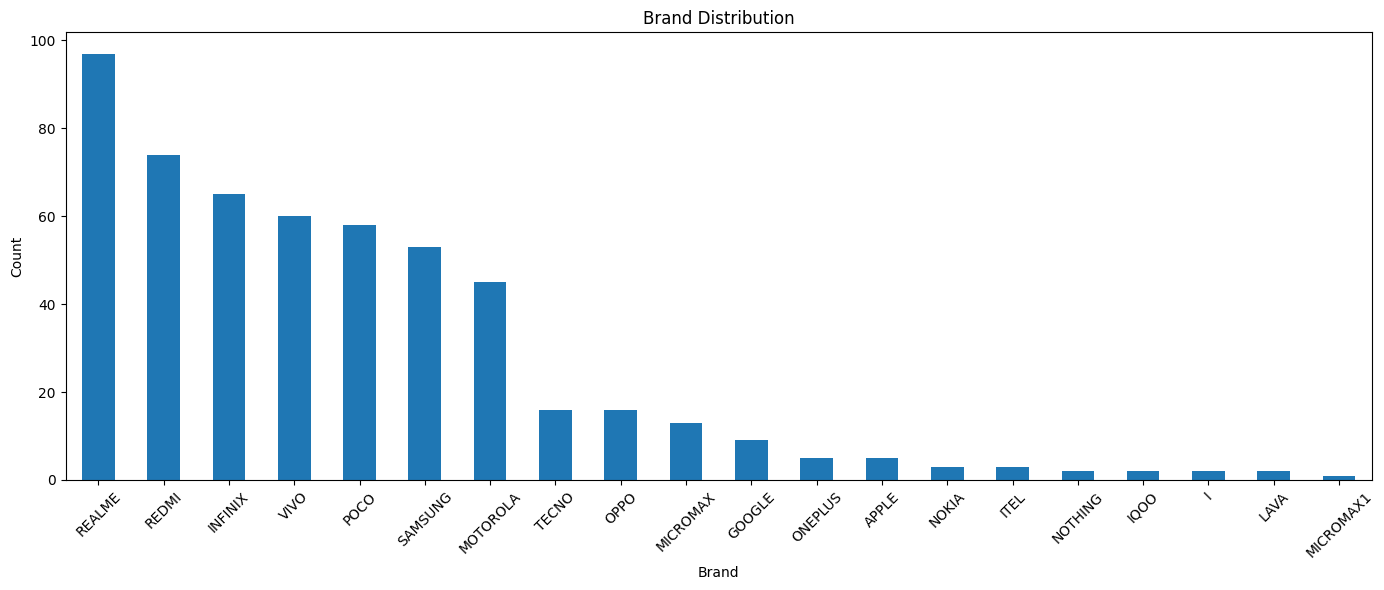

In [64]:
brand_counts=data["Brand"].value_counts()

plt.figure(figsize=(14,6))
brand_counts.plot(kind='bar')

plt.title("Brand Distribution")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

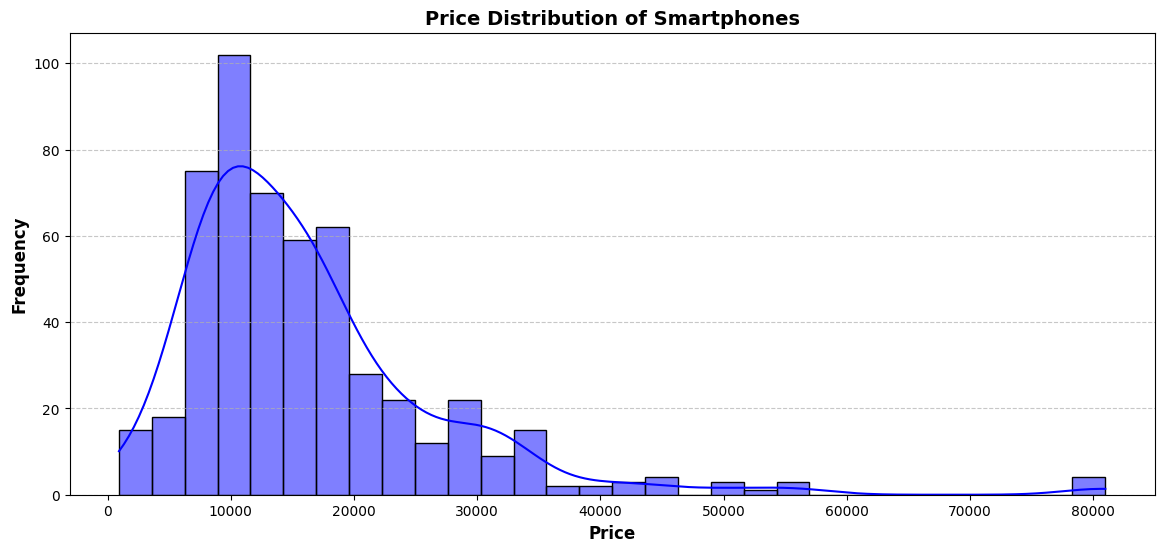

In [65]:
#univeriate analysis
#Price Distribution
plt.figure(figsize=(14,6))
sns.histplot(data["Price"],bins=30,kde=True,color='blue')

plt.title("Price Distribution of Smartphones",fontsize=14,fontweight="bold")
plt.xlabel("Price",fontsize=12,fontweight="bold")
plt.ylabel("Frequency",fontsize=12,fontweight="bold")

plt.grid(axis='y',linestyle='--',alpha=0.7)

plt.show()

C:\Users\vijay\AppData\Local\Temp\ipykernel_9780\130054809.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="dark")


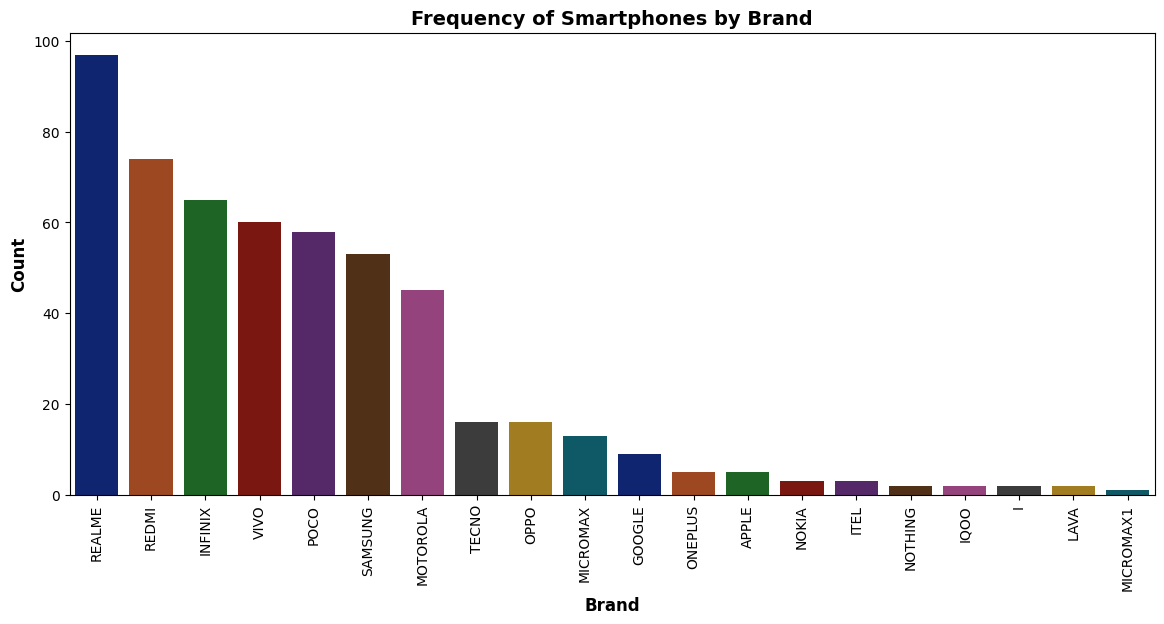

In [66]:
#univeriate analysis
#Brand counts
plt.figure(figsize=(14,6))
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="dark")

plt.title("Frequency of Smartphones by Brand",fontsize=14,fontweight="bold")
plt.xlabel("Brand",fontsize=12,fontweight="bold")
plt.ylabel("Count",fontsize=12,fontweight="bold")

plt.xticks(rotation=90)

plt.show()

In [67]:
#Average price by RAM

if 'RAM' in data.columns: ram_price = data.groupby('RAM')['Price'].mean() 
print("\nAverage Price by RAM:") 
print(ram_price)

#Average price by Model

if 'Model' in data.columns: model_price = data.groupby('Model')['Price'].mean().sort_values() 
print("\nAverage Price by Model:") 
print(model_price)


Average Price by RAM:
RAM
2     7864.702703
3     9893.400000
4    11889.972222
6    17459.100840
8    24218.122581
Name: Price, dtype: float64

Average Price by Model:
Model
redmi min                   920.0
micromax 1                 1299.0
micromax                   1332.0
micromax1                  1599.0
redmi mono                 1699.0
                           ...   
MOTOROLA Edge 30 Ultra    49999.0
APPLE iPhone 12           53999.0
Google Pixel 7            55999.0
SAMSUNG Galaxy S23 5G     79999.0
APPLE iPhone 14 Plus      80999.0
Name: Price, Length: 187, dtype: float64


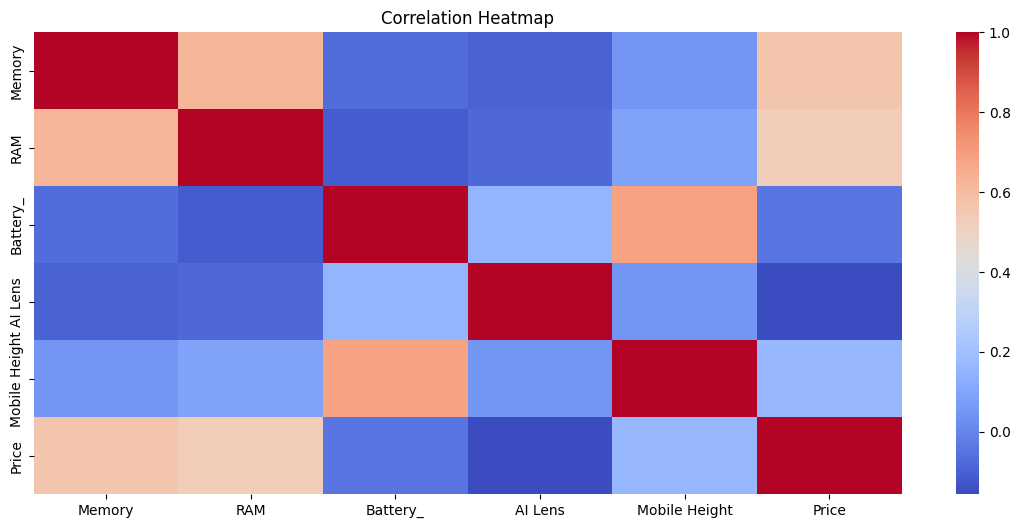

In [68]:
#Correlation Heatmap

plt.figure(figsize=(14,6)) 
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm') 
plt.title("Correlation Heatmap") 
plt.show()

C:\Users\vijay\AppData\Local\Temp\ipykernel_9780\2835396332.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RAM', y='Price',data=data, palette="dark")


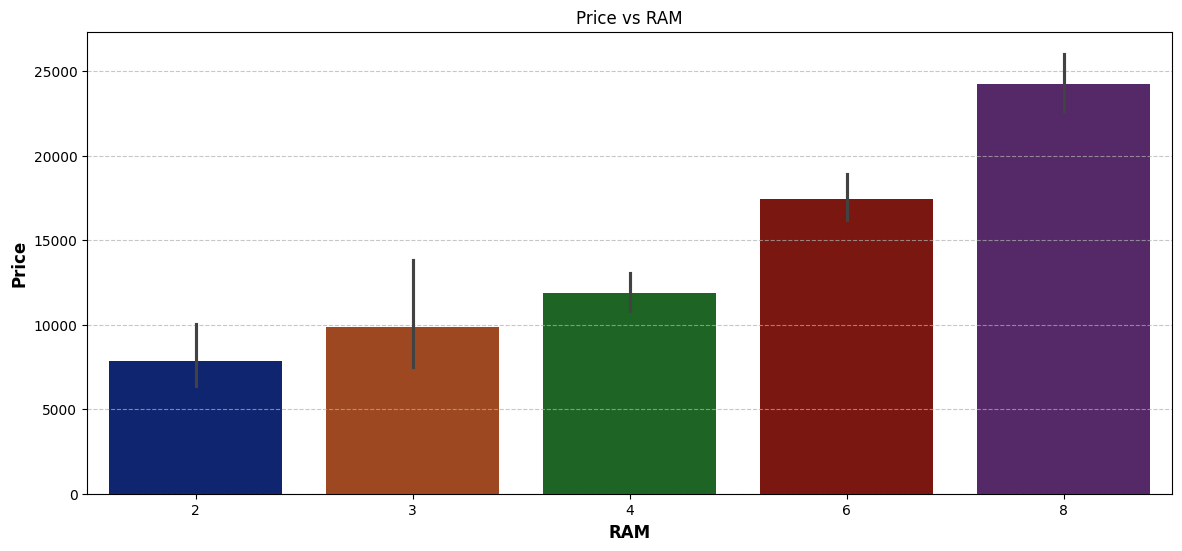

In [69]:
#Price vs RAM

if 'RAM' in data.columns: 
    plt.figure(figsize=(14,6)) 
    sns.barplot(x='RAM', y='Price',data=data, palette="dark") 
    plt.title("Price vs RAM") 
    plt.xlabel("RAM",fontsize=12,fontweight="bold")
    plt.ylabel("Price",fontsize=12,fontweight="bold")
    plt.grid(axis='y',linestyle='--',alpha=0.7)
    plt.show()

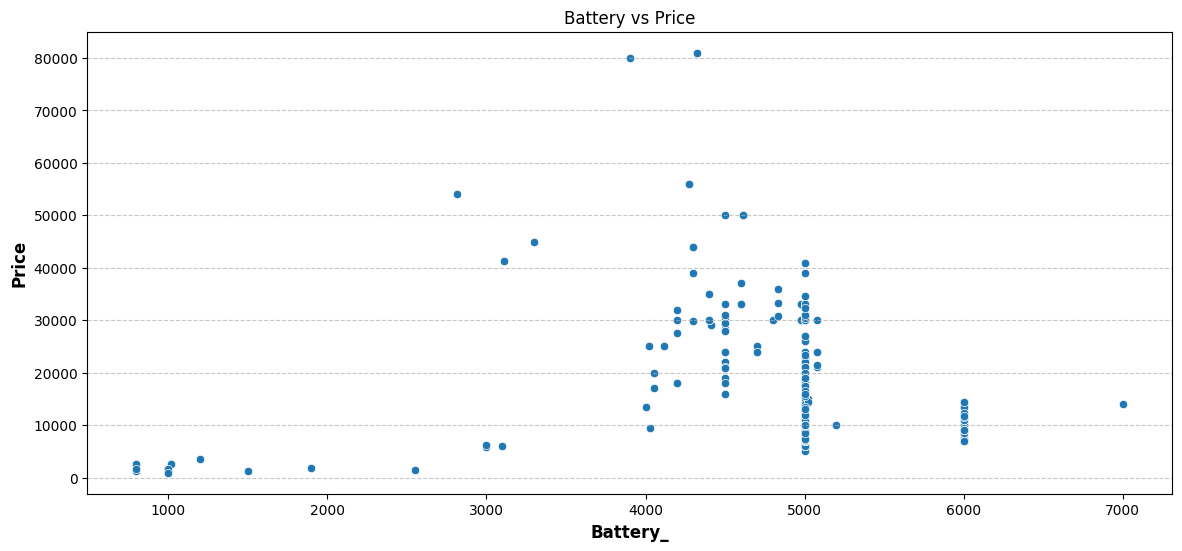

In [70]:
#Price vs Battery

if 'Battery_' in data.columns: 
    plt.figure(figsize=(14,6)) 
    sns.scatterplot(x='Battery_', y='Price', data=data) 
    plt.title("Battery vs Price") 
    plt.xlabel("Battery_",fontsize=12,fontweight="bold")
    plt.ylabel("Price",fontsize=12,fontweight="bold")
    plt.grid(axis='y',linestyle='--',alpha=0.7)
    plt.show()

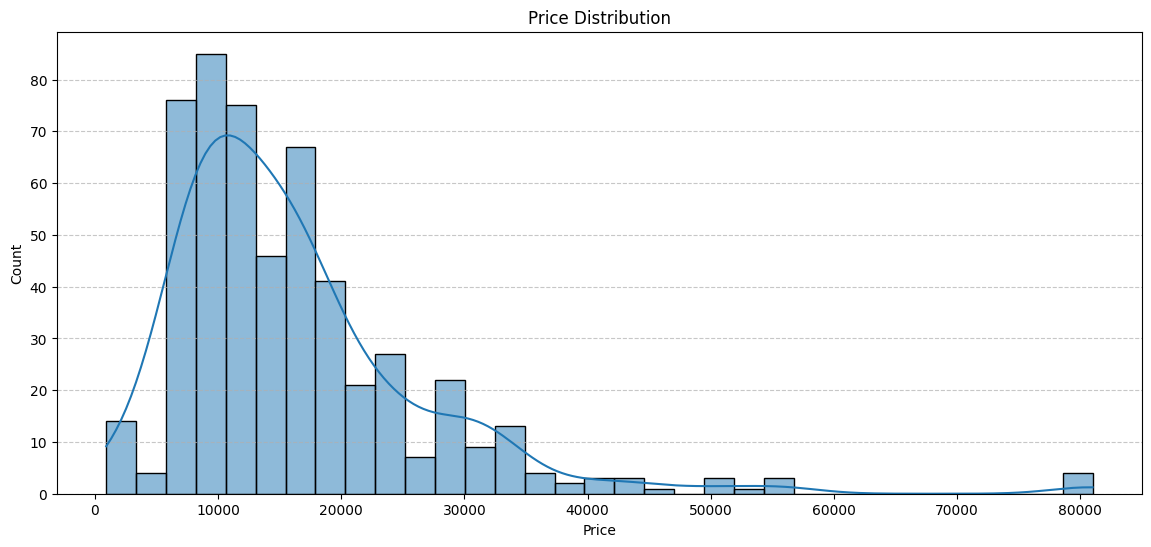

In [78]:
#Price Distribution
plt.figure(figsize=(14,6)) 
sns.histplot(data['Price'], kde=True) 
plt.title("Price Distribution")
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

In [ ]:
#Example rule-based estimation

def estimate_price(ram, battery): 
    base_price = data['Price'].mean() 
    price = base_price

# Simple logic
    if ram >= 8:
     price += 25000
    elif ram >= 4:
     price += 13000

    if battery >= 4500:
     price += 58000

    return round(price, 2)

print("Sample Prediction (Rule-based):") 
print("Estimated Price:", estimate_price(8, 25000))

Sample Prediction (Rule-based):
Estimated Price: 99305.78


In [73]:
#Final Insights
print("Insights:") 
print("- RAM strongly affects price") 
print("- Higher battery increases price moderately") 
print("- Premium models have higher average price") 
print("- Storage and processor also influence pricing")

Insights:
- RAM strongly affects price
- Higher battery increases price moderately
- Premium models have higher average price
- Storage and processor also influence pricing


In [74]:
#Conclusion
print("Conclusion:") 
print("This project analyzes mobile price using statistics and visualization.") 
print("Business can use these insights for pricing strategy.")

Conclusion:
This project analyzes mobile price using statistics and visualization.
Business can use these insights for pricing strategy.
